In [642]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph

In [643]:
ra_center, dec_center = 185.01551818847656,	1.1089283227920532
user = 'hyp0515'
password = 'PHFrCTavyczTCw/onxRGH537qhiLWqYSRuHB6WHE'
filter = 'HSC-R'

In [644]:
rect = downloadCutout.Rect.create(
    ra=	ra_center,
    dec=dec_center,
    sw="15arcsec",
    sh="15arcsec",
    variance=True,
    mask=True,
    filter=filter,
)

images = downloadCutout.download(rect, user=user, password=password)
_, image_data = images[0]
image_hdu = astropy.io.fits.open(io.BytesIO(image_data))
image_hdu.info()
image = image_hdu[1].data
mask  = image_hdu[2].data
print(np.max(mask), np.min(mask))
print(mask[mask.shape[0]//2, mask.shape[1]//2])
var   = image_hdu[3].data

psfreq = downloadPsf.PsfRequest.create(
    ra=ra_center,
    dec=dec_center,
    filter=filter
)
psfs = downloadPsf.download(psfreq, user=user, password=password)
print(psfs)
_, psf_data = psfs[0]
psf_hdu = astropy.io.fits.open(io.BytesIO(psf_data))
psf_hdu.info()
psf = psf_hdu[0].data


KeyboardInterrupt: 

11850.424863147044


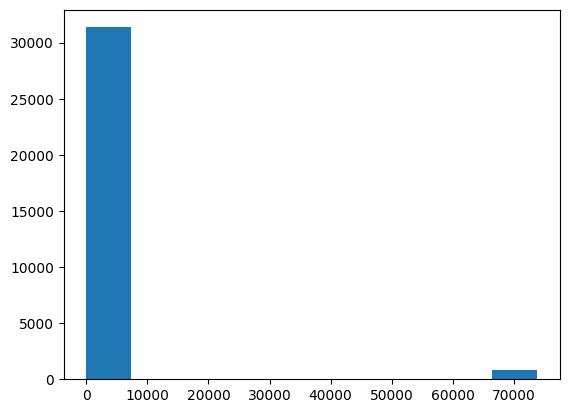

In [ ]:
print(np.std(mask.flatten()))
plt.hist(mask.flatten())
plt.show()

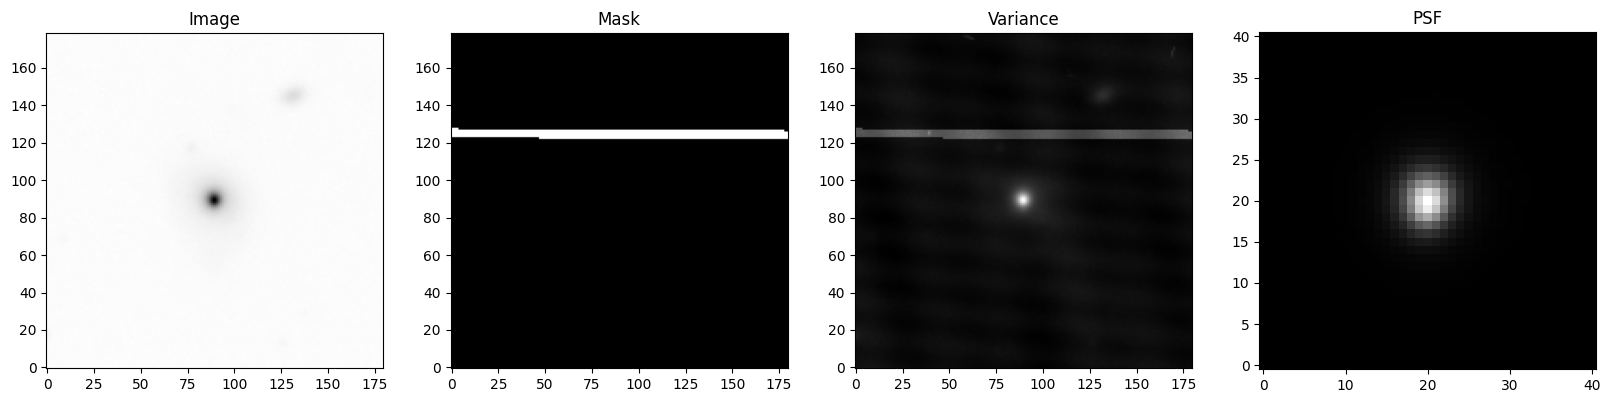

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.show()

In [ ]:
threshold = detect_threshold(image, 10,)
npixels = 200  # minimum number of connected pixels
segmap = detect_sources(image, threshold, npixels)
segmap = np.array(segmap)
segmap = np.where(segmap != segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)], 0, 1)
print(segmap.shape)

(179, 180)


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_89214/2459929732.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  segmap = np.array(segmap)


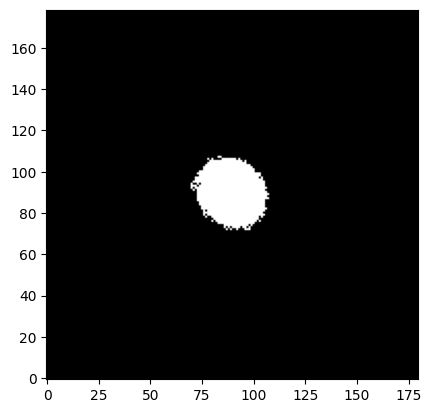

In [ ]:
plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()

In [ ]:
new_mask = np.zeros_like(mask)
new_mask[segmap == 1] = 0
new_mask[segmap == 0] = np.where((mask[segmap == 0]>=np.min(mask[segmap == 0])+np.std(mask.flatten()))|(image[segmap == 0]>=np.max(image[segmap == 1])*2/3), 1, 0)
mask = new_mask.astype(bool)

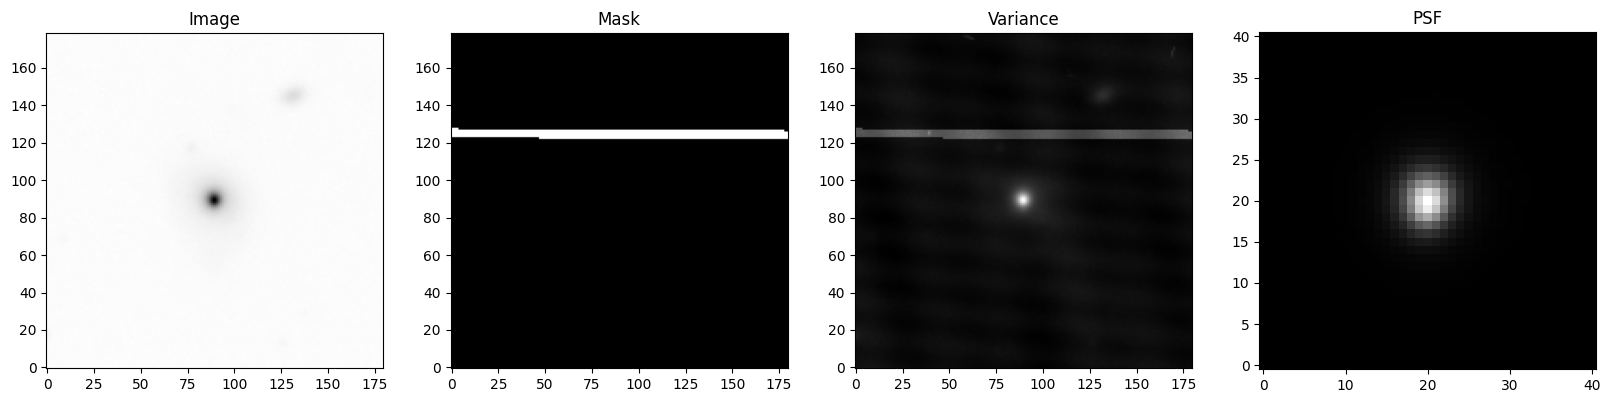

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.show()

In [ ]:
start = time.time()
source_morphs = statmorph.source_morphology(image=image, segmap=segmap, psf=psf, weightmap=np.sqrt(var), mask=mask)
print('Time: %g s.' % (time.time() - start))

Time: 0.181182 s.


In [ ]:
morph = source_morphs[0]

In [ ]:
print('BASIC MEASUREMENTS (NON-PARAMETRIC)')
print('Gini =', morph.gini)
print('M20 =', morph.m20)
print('F(G, M20) =', morph.gini_m20_bulge)
print('S(G, M20) =', morph.gini_m20_merger)
print('C =', morph.concentration)
print('A =', morph.asymmetry)
print('S =', morph.smoothness)
print('A_s =', morph.shape_asymmetry)
print()
print('SERSIC MODEL')
print('sersic_amplitude =', morph.sersic_amplitude)
print('sersic_rhalf =', morph.sersic_rhalf)
print('sersic_n =', morph.sersic_n)
print('sersic_xc =', morph.sersic_xc)
print('sersic_yc =', morph.sersic_yc)
print('sersic_ellip =', morph.sersic_ellip)
print('sersic_theta =', morph.sersic_theta)
print('sersic_chi2_dof =', morph.sersic_chi2_dof)

BASIC MEASUREMENTS (NON-PARAMETRIC)
Gini = 0.5588084817017561
M20 = -2.144788798388396
F(G, M20) = 0.29244062170685137
S(G, M20) = -0.07190524609124854
C = 3.6333574366821226
A = 0.032917737270071586
S = 0.0009223686358950703
A_s = 0.2512347318779923

SERSIC MODEL
sersic_amplitude = 0.28245380354793304
sersic_rhalf = 30.56384987169529
sersic_n = 8.044559155292715
sersic_xc = 89.34493475695103
sersic_yc = 89.17648358565339
sersic_ellip = 0.13651210665450988
sersic_theta = 2.2860445914496217
sersic_chi2_dof = 3.091173411648935


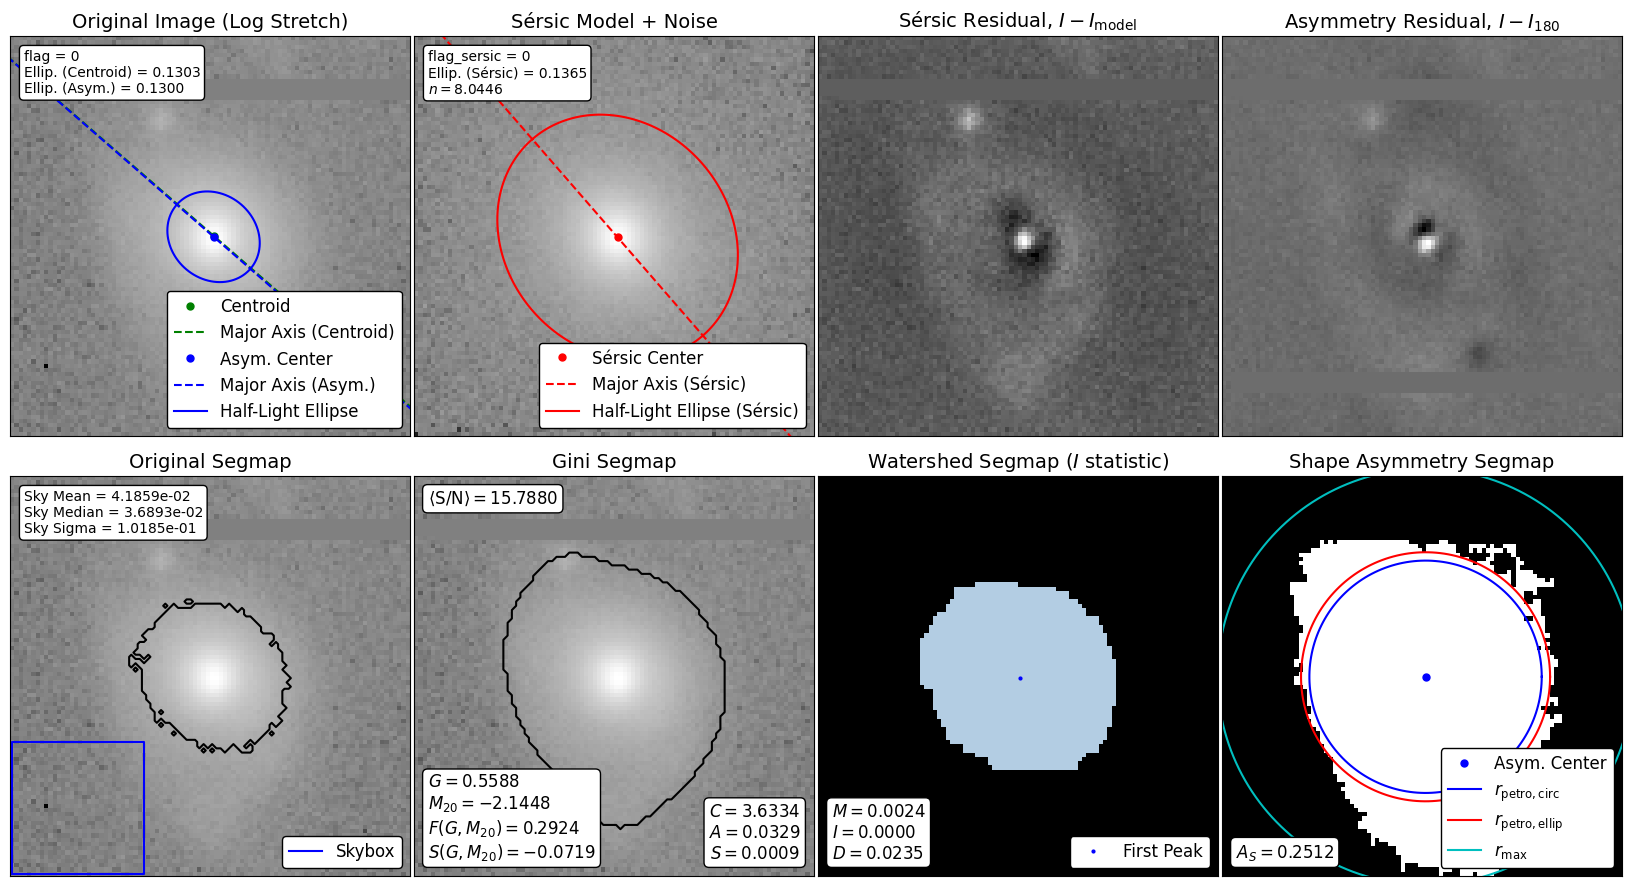

In [ ]:
from statmorph.utils.image_diagnostics import make_figure
fig = make_figure(morph)

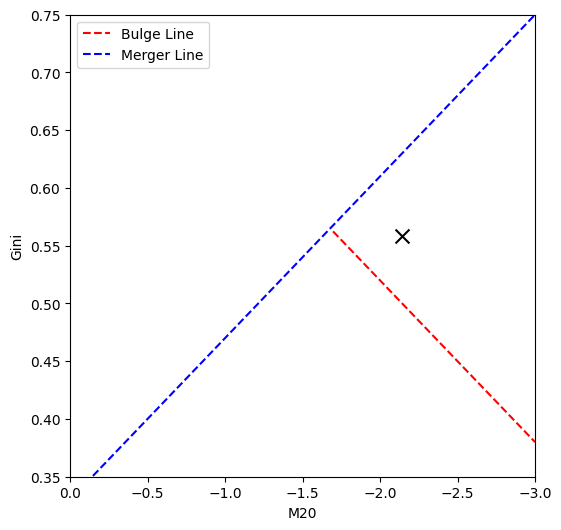

In [ ]:
x = np.linspace(0, -3, 100)
merger_line = -0.14 * x + 0.33
bulge_line = 0.14 * x + 0.8
plt.figure(figsize=(6, 6))
plt.scatter(morph.m20, morph.gini, s=100, color='k', marker='x')
plt.plot(x[bulge_line<merger_line], bulge_line[bulge_line<merger_line], color='red', linestyle='--', label='Bulge Line')
plt.plot(x, merger_line, color='blue', linestyle='--', label='Merger Line')
plt.xlim((0, -3))
plt.ylim((0.35, 0.75))
plt.xlabel('M20')
plt.ylabel('Gini')
plt.legend()
plt.show()

In [ ]:
print(-0.693*morph.m20 + 4.95*morph.gini -3.96)
print(0.139*morph.m20 + 0.990*morph.gini -0.327)

0.29244062170685137
-0.07190524609124854
